In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data
data = {
    "2022": {
        "Boshlang'ich": {"amount": 41760667, "number": 286},
        "O'rta": {"amount": 79313267, "number": 28},
        "Professional": {"amount": 316447235, "number": 102},
        "Jami": {"amount": 437521169, "number": 416}
    },
    "2023": {
        "Boshlang'ich": {"amount": 495628989, "number": 441},
        "O'rta": {"amount": 556365306, "number": 138},
        "Professional": {"amount": 532489149, "number": 386},
        "Jami": {"amount": 1584483444, "number": 965}
    },
    "2024": {
        "Boshlang'ich": {"amount": 532128246, "number": 173},
        "O'rta": {"amount": 309079403, "number": 106},
        "Professional": {"amount": 110837244 + 2301582315, "number": 105 + 540},
        "B2 va Undan yuqori": {"amount": 544969009, "number": 77},
        "Jami": {"amount": 3798596217 + 450000000, "number": 1001}
    }
}


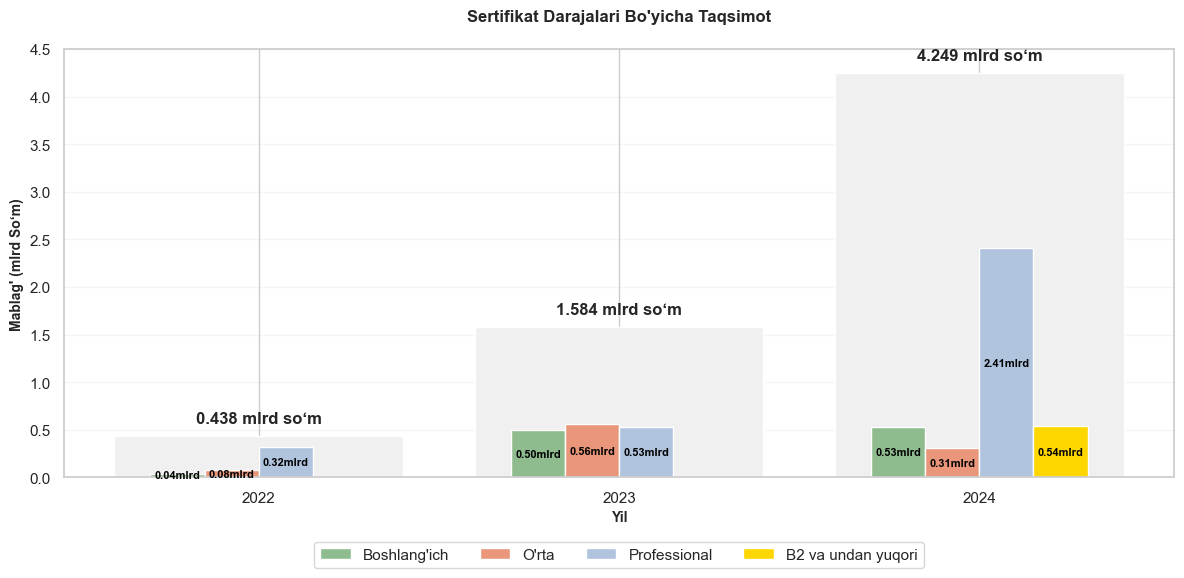

In [43]:
# Years and categories
years = ["2022", "2023", "2024"]

# Converting amounts to billions (mlrd)
boshlangich = [data[year]["Boshlang'ich"]["amount"] / 1e9 for year in years]
orta = [data[year]["O'rta"]["amount"] / 1e9 for year in years]
professional = [data[year].get("Professional", {"amount": 0})["amount"] / 1e9 for year in years]
b2_va_yuqori = [data[year].get("B2 va Undan yuqori", {"amount": 0})["amount"] / 1e9 for year in years]
jami = [data[year]["Jami"]["amount"] / 1e9 for year in years]

# Set up the plot
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Plot bars
x = np.arange(len(years))
width = 0.15

plt.bar(x, jami, width=0.8, color='#F0F0F0', zorder=1)

plt.bar(x - 1.5*width, boshlangich, width, label="Boshlang'ich", color='#8FBC8F', zorder=2)
plt.bar(x - 0.5*width, orta, width, label="O'rta", color='#E9967A', zorder=2)
plt.bar(x + 0.5*width, professional, width, label='Professional', color='#B0C4DE', zorder=2)
plt.bar(x + 1.5*width, b2_va_yuqori, width, label='B2 va undan yuqori', color='#FFD700', zorder=2)

# Add value labels with 3 decimal places
def add_labels(x, values):
    for i, v in enumerate(values):
        if v > 0:
            plt.text(x[i], v/2, f'{v:.2f}mlrd', ha='center', va='center', 
                     fontsize=8, color='black', fontweight='bold')

# Add category value labels
add_labels(x - 1.5*width, boshlangich)
add_labels(x - 0.5*width, orta)
add_labels(x + 0.5*width, professional)
add_labels(x + 1.5*width, b2_va_yuqori)

# Add total labels on top with 3 decimal places
for i, total in enumerate(jami):
    plt.text(x[i], total + 0.1, f'{total:.3f} mlrd so‘m', ha='center', va='bottom', fontweight='bold')

# Customize y-axis ticks with 0.5 intervals
y_max = max(jami) + 1  # Add some space above the maximum total
plt.yticks(np.arange(0, y_max, 0.5))

# Rest of the visualization settings remain the same
plt.title("Sertifikat Darajalari Bo'yicha Taqsimot", pad=20, fontsize=12, fontweight='bold')
plt.xlabel('Yil', fontsize=10, fontweight='bold')
plt.ylabel("Mablag' (mlrd So‘m)", fontsize=10, fontweight='bold')
plt.ylim(0, 4.5)
plt.grid(axis='y', linestyle='-', alpha=0.2, zorder=0)
ax.set_axisbelow(True)
plt.xticks(x, years)
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, borderaxespad=0)
plt.tight_layout()
plt.show()